## Machine Learning

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/Base.csv")
df.head()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,...,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,...,0,200.0,0,INTERNET,3.743048,other,0,1,0,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  str    
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000000 non-nul

In [3]:
df['device_distinct_emails_8w'].unique()        

array([ 1,  2,  0, -1])

In [4]:
pd.set_option('display.max_columns', None)
df.groupby("fraud_bool").mean(numeric_only=True)

,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,credit_risk_score,email_is_free,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,session_length_in_minutes,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
fraud_bool,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.561313,0.494815,16.839647,86.273232,33.609125,1.025383,8.713907,1572.138693,5670.664988,4771.528849,4857.444566,184.923747,9.526521,130.469904,0.528423,0.418906,0.890112,10.843426,0.224533,512.303162,0.024962,7.537306,0.579571,1.017630,0.0,3.285582
1,0.686635,0.393161,5.861365,114.801161,40.858645,1.054615,3.962009,1622.311542,5183.913444,4613.138798,4755.844185,133.976426,7.443195,177.590353,0.661075,0.253060,0.850576,10.469580,0.084414,833.986762,0.050322,8.229520,0.341645,1.079427,0.0,3.565962


#### Hypothesis Testing

**For numerical features**

H₀: mean is the same for fraud and non-fraud

H₁: mean is different

In [5]:
from scipy.stats import ttest_ind

fraud = df[df["fraud_bool"] == 1]["income"]
non_fraud = df[df["fraud_bool"] == 0]["income"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 0.0


In [6]:
fraud = df[df["fraud_bool"] == 1]["name_email_similarity"]
non_fraud = df[df["fraud_bool"] == 0]["name_email_similarity"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 2.2555045287440515e-295


In [7]:
fraud = df[df["fraud_bool"] == 1]["prev_address_months_count"]
non_fraud = df[df["fraud_bool"] == 0]["prev_address_months_count"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 1.9858314927323405e-149


In [8]:
fraud = df[df["fraud_bool"] == 1]["current_address_months_count"]
non_fraud = df[df["fraud_bool"] == 0]["current_address_months_count"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 4.02208167285188e-249


In [9]:
fraud = df[df["fraud_bool"] == 1]["customer_age"]
non_fraud = df[df["fraud_bool"] == 0]["customer_age"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 0.0


In [10]:
fraud = df[df["fraud_bool"] == 1]["days_since_request"]
non_fraud = df[df["fraud_bool"] == 0]["days_since_request"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 0.5705247727066658


In [11]:
fraud = df[df["fraud_bool"] == 1]["intended_balcon_amount"]
non_fraud = df[df["fraud_bool"] == 0]["intended_balcon_amount"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 7.408216720914384e-133


In [12]:
fraud = df[df["fraud_bool"] == 1]["zip_count_4w"]
non_fraud = df[df["fraud_bool"] == 0]["zip_count_4w"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 1.868283894070342e-07


In [13]:
fraud = df[df["fraud_bool"] == 1]["velocity_6h"]
non_fraud = df[df["fraud_bool"] == 0]["velocity_6h"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 5.0196890745190833e-64


In [14]:
fraud = df[df["fraud_bool"] == 1]["velocity_24h"]
non_fraud = df[df["fraud_bool"] == 0]["velocity_24h"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 4.9218828027128204e-29


In [15]:
fraud = df[df["fraud_bool"] == 1]["velocity_4w"]
non_fraud = df[df["fraud_bool"] == 0]["velocity_4w"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 8.68740945769277e-31


In [16]:
fraud = df[df["fraud_bool"] == 1]["bank_branch_count_8w"]
non_fraud = df[df["fraud_bool"] == 0]["bank_branch_count_8w"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 5.397590093755087e-31


In [17]:
fraud = df[df["fraud_bool"] == 1]["date_of_birth_distinct_emails_4w"]
non_fraud = df[df["fraud_bool"] == 0]["date_of_birth_distinct_emails_4w"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 0.0


In [18]:
fraud = df[df["fraud_bool"] == 1]["credit_risk_score"]
non_fraud = df[df["fraud_bool"] == 0]["credit_risk_score"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 0.0


In [19]:
fraud = df[df["fraud_bool"] == 1]["email_is_free"]
non_fraud = df[df["fraud_bool"] == 0]["email_is_free"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 1.2167188766395695e-169


In [20]:
fraud = df[df["fraud_bool"] == 1]["phone_home_valid"]
non_fraud = df[df["fraud_bool"] == 0]["phone_home_valid"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 1.7348994849322754e-270


In [21]:
fraud = df[df["fraud_bool"] == 1]["phone_mobile_valid"]
non_fraud = df[df["fraud_bool"] == 0]["phone_mobile_valid"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 1.140351645803951e-39


In [22]:
fraud = df[df["fraud_bool"] == 1]["bank_months_count"]
non_fraud = df[df["fraud_bool"] == 0]["bank_months_count"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 0.0012717662833232047


In [23]:
fraud = df[df["fraud_bool"] == 1]["has_other_cards"]
non_fraud = df[df["fraud_bool"] == 0]["has_other_cards"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 6.3475034012951e-271


In [24]:
fraud = df[df["fraud_bool"] == 1]["proposed_credit_limit"]
non_fraud = df[df["fraud_bool"] == 0]["proposed_credit_limit"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 0.0


In [25]:
fraud = df[df["fraud_bool"] == 1]["foreign_request"]
non_fraud = df[df["fraud_bool"] == 0]["foreign_request"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 5.7227304122397784e-64


In [26]:
fraud = df[df["fraud_bool"] == 1]["session_length_in_minutes"]
non_fraud = df[df["fraud_bool"] == 0]["session_length_in_minutes"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 2.26457112944074e-19


In [27]:
fraud = df[df["fraud_bool"] == 1]["keep_alive_session"]
non_fraud = df[df["fraud_bool"] == 0]["keep_alive_session"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 0.0


In [28]:
fraud = df[df["fraud_bool"] == 1]["device_distinct_emails_8w"]
non_fraud = df[df["fraud_bool"] == 0]["device_distinct_emails_8w"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 2.2755392243268834e-279


In [29]:
fraud = df[df["fraud_bool"] == 1]["device_fraud_count"]
non_fraud = df[df["fraud_bool"] == 0]["device_fraud_count"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: nan


In [30]:
fraud = df[df["fraud_bool"] == 1]["month"]
non_fraud = df[df["fraud_bool"] == 0]["month"]

stat, p_value = ttest_ind(fraud, non_fraud)

print("p-value:", p_value)

p-value: 4.475818725834844e-40


### Results of Statistical Tests for Numerical Features

Independent t-tests were conducted to evaluate whether numerical features differ significantly between fraudulent and non-fraudulent transactions.

The results show that all numerical features, with the exception of `days_since_request`, have p-values below the 0.05 significance level. This indicates that their mean values differ significantly between the two groups, suggesting that they are relevant predictors of fraud.

In contrast, `days_since_request` returned a p-value greater than 0.05, meaning that there is insufficient evidence to conclude a significant difference between fraud and non-fraud transactions for this feature.

As a result, this variable may have limited predictive power when considered independently. However, it may still be retained in the model to capture potential nonlinear effects or interactions with other features.


**For categorical features**

H₀: independent from fraud

H₁: dependent on fraud

In [31]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df["payment_type"], df["fraud_bool"])

stat, p, dof, expected = chi2_contingency(contingency)

print("p-value:", p)

p-value: 0.0


In [32]:
contingency = pd.crosstab(df["employment_status"], df["fraud_bool"])

stat, p, dof, expected = chi2_contingency(contingency)

print("p-value:", p)

p-value: 0.0


In [33]:
contingency = pd.crosstab(df["housing_status"], df["fraud_bool"])

stat, p, dof, expected = chi2_contingency(contingency)

print("p-value:", p)

p-value: 0.0


In [34]:
contingency = pd.crosstab(df["source"], df["fraud_bool"])

stat, p, dof, expected = chi2_contingency(contingency)

print("p-value:", p)

p-value: 0.00011111400181929854


In [35]:
contingency = pd.crosstab(df["device_os"], df["fraud_bool"])

stat, p, dof, expected = chi2_contingency(contingency)

print("p-value:", p)

p-value: 0.0


#### Preparing data

In [36]:
X = df.drop(columns=["fraud_bool"])
y = df["fraud_bool"]

In [37]:
X = pd.get_dummies(X, drop_first=True)

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [39]:
y.value_counts(normalize=True)

fraud_bool
0    0.988971
1    0.011029
Name: proportion, dtype: float64

In [40]:
from sklearn.utils import class_weight

class_weights = "balanced"

##### Class Imbalance

The dataset exhibits a strong class imbalance, with fraudulent transactions representing only a small fraction of the total observations. This imbalance can bias the model toward predicting the majority class.

To address this issue, class weights will be used in the Logistic Regression and Random Forest models, ensuring that fraudulent cases are given higher importance during training.


#### Training models

##### Model Selection Rationale

Three different machine learning models were selected to capture a range of modeling approaches and compare their performance on the fraud detection task.

Logistic Regression was chosen as a baseline model due to its simplicity, interpretability, and widespread use in classification problems. It provides a reference point to evaluate whether more complex models offer meaningful improvements.

Random Forest was selected as a tree-based ensemble method capable of capturing non-linear relationships and interactions between features. It is robust to noise and performs well on structured data.

Gradient Boosting was included as a more advanced ensemble technique that builds models sequentially, focusing on correcting previous errors. This approach is known to achieve strong performance in tabular datasets and is particularly effective in detecting subtle patterns, such as those present in fraud detection.

By comparing these three models, the analysis ensures a comprehensive evaluation across different levels of model complexity and learning strategies.


##### Logistic Model

In [41]:
# cross validation
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print("ROC-AUC scores:", scores)
print("Mean ROC-AUC:", scores.mean())
print("Std:", scores.std())

ROC-AUC scores: [0.84791913 0.88280271 0.89615662 0.87063213 0.87621968]
Mean ROC-AUC: 0.8747460549033415
Std: 0.015887742812691855


In [42]:
# confidence interval
import numpy as np

mean = scores.mean()
std = scores.std()
n = len(scores)

ci_lower = mean - 1.96 * (std / np.sqrt(n))
ci_upper = mean + 1.96 * (std / np.sqrt(n))

print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

95% CI: [0.8608, 0.8887]


##### Cross-Validated Performance

A 5-fold cross-validation approach was used to evaluate the Logistic Regression model, ensuring robust performance estimation across different data splits. The model achieved a mean ROC-AUC of approximately 0.875.

To quantify the uncertainty of this estimate, a 95% confidence interval was computed, resulting in a range of approximately [0.86, 0.89]. This relatively narrow interval indicates that the model performs consistently across different folds and generalizes well to unseen data.


##### Random Forest

In [43]:
# cross validation
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,  
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# cross validation
scores_rf = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print("ROC-AUC scores:", scores_rf)
print("Mean ROC-AUC:", scores_rf.mean())
print("Std:", scores_rf.std())

ROC-AUC scores: [0.76437524 0.80773776 0.84401431 0.81598052 0.81727508]
Mean ROC-AUC: 0.8098765830396324
Std: 0.025815990848340152


In [44]:
# confidence interval
mean = scores_rf.mean()
std = scores_rf.std()
n = len(scores_rf)

ci_lower = mean - 1.96 * (std / np.sqrt(n))
ci_upper = mean + 1.96 * (std / np.sqrt(n))

print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

95% CI: [0.7872, 0.8325]


##### Gradient Boosting

In [45]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# cross validation
scores_gb = cross_val_score(
    gb,
    X,
    y,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1  
)

print("ROC-AUC scores:", scores_gb)
print("Mean ROC-AUC:", scores_gb.mean())
print("Std:", scores_gb.std())

ROC-AUC scores: [0.86747794 0.88771209 0.83014148 0.87060509 0.8729822 ]
Mean ROC-AUC: 0.8657837592535443
Std: 0.01912671877235696


In [46]:
# confidence interval
mean = scores_gb.mean()
std = scores_gb.std()
n = len(scores_gb)

ci_lower = mean - 1.96 * (std / np.sqrt(n))
ci_upper = mean + 1.96 * (std / np.sqrt(n))

print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

95% CI: [0.8490, 0.8825]


##### Model Comparison and Final Selection

The three models were evaluated using 5-fold cross-validation with ROC-AUC as the performance metric, and 95% confidence intervals were computed to assess statistical reliability.

**Logistic Regression** achieved the highest mean ROC-AUC (0.875), followed closely by **Gradient Boosting** (0.866). The confidence intervals of these two models overlap significantly, indicating that their performance differences are not statistically significant.

**Random Forest** showed a clearly lower performance, with a mean ROC-AUC of 0.81 and a non-overlapping confidence interval, suggesting inferior predictive capability.

Given the comparable performance between Logistic Regression and Gradient Boosting, Logistic Regression was selected as the final model due to its simplicity, interpretability, and lower computational cost.


#### Feature Importance

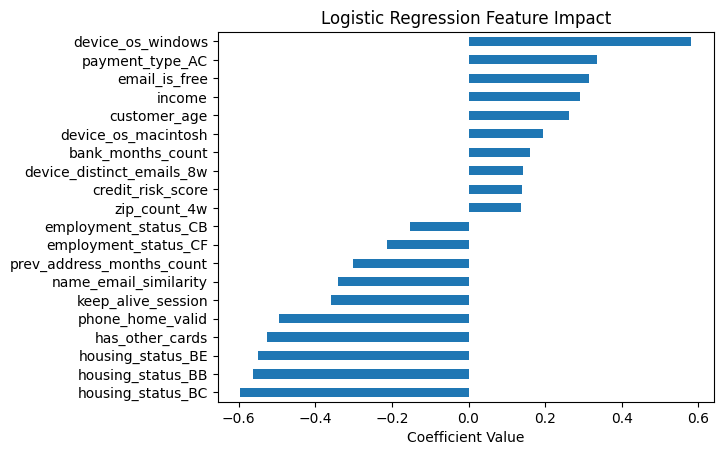

In [87]:
import matplotlib.pyplot as plt

def plot_logistic_coefficients(model, X, top_n=10):
    coef = pd.Series(
        model.named_steps["model"].coef_[0],
        index=X.columns
    )    
    top_positive = coef.sort_values(ascending=False).head(top_n)
    top_negative = coef.sort_values().head(top_n)
    
    combined = pd.concat([top_negative, top_positive])
    
    plt.figure()
    combined.sort_values().plot(kind='barh')
    plt.title("Logistic Regression Feature Impact")
    plt.xlabel("Coefficient Value")
    plt.show()

plot_logistic_coefficients(final_model, X_train)

### Feature Selection - Logistic Regression

In [76]:
# Train the model
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

final_model.fit(X_train, y_train)

# Extract coefficients
coeffs = pd.Series(
    final_model.named_steps["model"].coef_[0],
    index=X.columns
)

# Sort
coeffs_sorted = coeffs.sort_values()

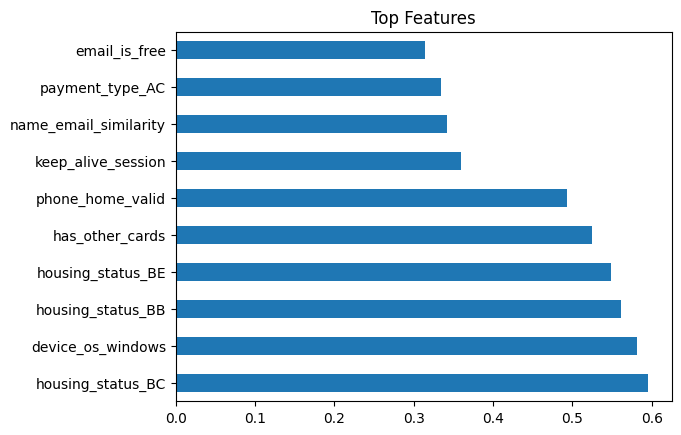

In [77]:
coeffs.abs().sort_values(ascending=False).head(10).plot(kind="barh")
plt.title("Top Features")
plt.show()

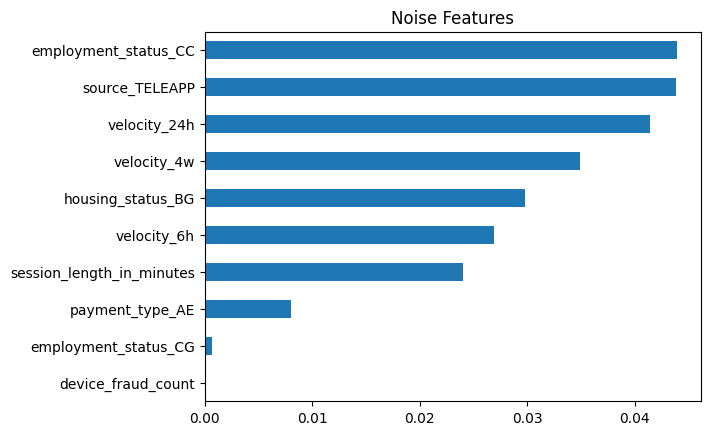

In [78]:
coeffs.abs().sort_values().head(10).plot(kind="barh")
plt.title("Noise Features")
plt.show()

In [81]:
X_reduced = X.drop(columns=[
    "days_since_request",
    "employment_status_CG",
    "employment_status_CC",
    "payment_type_AE",
    "housing_status_BG",
    "source_TELEAPP",
    "device_fraud_count"
])

In [82]:
# 4. Define pipeline (IMPORTANT: scaling inside CV)
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

# 5. Run cross-validation
new_scores = cross_val_score(
    pipeline,
    X_reduced,
    y,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1  # speeds up computation
)

# 6. Print results
print("ROC-AUC scores:", scores)
print("Mean ROC-AUC:", scores.mean())
print("Std ROC-AUC:", scores.std())

# 7. Optional: Confidence Interval
import numpy as np

ci_lower = scores.mean() - 1.96 * scores.std()
ci_upper = scores.mean() + 1.96 * scores.std()

print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

ROC-AUC scores: [0.84791913 0.88280271 0.89615662 0.87063213 0.87621968]
Mean ROC-AUC: 0.8747460549033415
Std ROC-AUC: 0.015887742812691855
95% CI: [0.8436, 0.9059]


##### Impact of Feature Selection

Feature selection was performed by removing variables with low statistical significance and low model importance. However, after retraining the model and evaluating it using cross-validation, no improvement in ROC-AUC was observed. Additionally, the variability of the model increased, as indicated by a higher standard deviation and a wider confidence interval.

This suggests that even features with low individual importance may still contribute useful information when combined with others. Therefore, the full feature set was retained to preserve model performance and stability.

This result highlights the importance of validating feature selection decisions empirically rather than relying solely on statistical tests or coefficient magnitude.


#### Evaluate on test set

In [83]:
from sklearn.metrics import roc_auc_score

y_pred_proba = final_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Test ROC-AUC:", roc_auc)

Test ROC-AUC: 0.8734804753526505


##### Classification report

In [84]:
from sklearn.metrics import classification_report

y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.80      0.89    197801
           1       0.04      0.78      0.08      2199

    accuracy                           0.80    200000
   macro avg       0.52      0.79      0.49    200000
weighted avg       0.99      0.80      0.88    200000



#### Threshold Tuning

##### Optimal Threshold Tuning using F1-score

In [98]:
from sklearn.metrics import precision_recall_curve

# Compute precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Compute F1-score
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

# Find best threshold
best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("Best Threshold:", best_threshold)
print("Best F1-score:", best_f1)

Best Threshold: 0.8898748520879133
Best F1-score: 0.21070141387500158


In [58]:
# Applying threshold
y_pred_optimal = (y_pred_proba > best_threshold).astype(int)

# Evaluating
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_optimal))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99    197801
           1       0.15      0.35      0.21      2199

    accuracy                           0.97    200000
   macro avg       0.57      0.66      0.60    200000
weighted avg       0.98      0.97      0.98    200000



##### Interpretation of Optimal Threshold Results

The optimal threshold obtained by maximizing the F1-score was approximately 0.889. This relatively high threshold makes the model more conservative, meaning that only transactions with a high predicted probability are classified as fraudulent.

As a result, precision improved significantly (0.15), reducing the number of false positives. However, recall dropped to 0.35, indicating that a large proportion of fraudulent transactions are not detected.

This outcome reflects the trade-off inherent in optimizing the F1-score, which balances precision and recall equally. In the context of fraud detection, this may not be ideal, as missing fraudulent transactions can be more costly than investigating false positives.

Therefore, while the threshold is mathematically optimal in terms of F1-score, a lower threshold may be more appropriate in practice to achieve higher fraud detection rates.


#### Final threshold (business-aware)

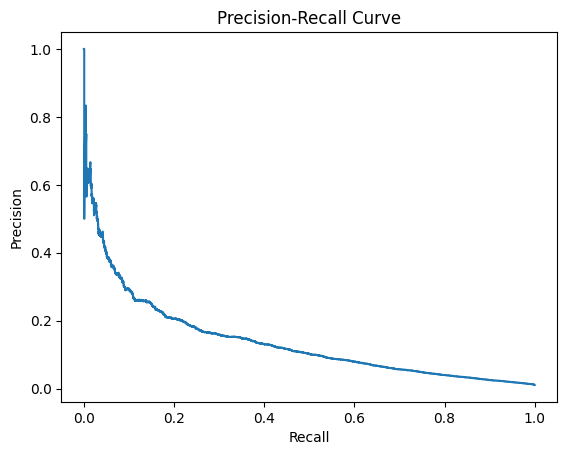

In [100]:
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

- Recall - % of frauds catched
- Precision - % of detected frauds that are actually fraud

In [60]:
for i in range(0, len(thresholds), 1000):
    print(f"Threshold: {thresholds[i]:.2f}, Precision: {precision[i]:.2f}, Recall: {recall[i]:.2f}")

Threshold: 0.00, Precision: 0.01, Recall: 1.00
Threshold: 0.01, Precision: 0.01, Recall: 1.00
Threshold: 0.01, Precision: 0.01, Recall: 1.00
Threshold: 0.01, Precision: 0.01, Recall: 1.00
Threshold: 0.01, Precision: 0.01, Recall: 1.00
Threshold: 0.02, Precision: 0.01, Recall: 1.00
Threshold: 0.02, Precision: 0.01, Recall: 1.00
Threshold: 0.02, Precision: 0.01, Recall: 1.00
Threshold: 0.02, Precision: 0.01, Recall: 1.00
Threshold: 0.02, Precision: 0.01, Recall: 1.00
Threshold: 0.03, Precision: 0.01, Recall: 1.00
Threshold: 0.03, Precision: 0.01, Recall: 1.00
Threshold: 0.03, Precision: 0.01, Recall: 1.00
Threshold: 0.03, Precision: 0.01, Recall: 1.00
Threshold: 0.03, Precision: 0.01, Recall: 1.00
Threshold: 0.03, Precision: 0.01, Recall: 1.00
Threshold: 0.03, Precision: 0.01, Recall: 1.00
Threshold: 0.04, Precision: 0.01, Recall: 1.00
Threshold: 0.04, Precision: 0.01, Recall: 1.00
Threshold: 0.04, Precision: 0.01, Recall: 1.00
Threshold: 0.04, Precision: 0.01, Recall: 1.00
Threshold: 0.

In [61]:
# Defining minimum recall
min_recall = 0.65

valid_idx = np.where(recall[:-1] >= min_recall)[0]

# Among those, pick best precision
best_idx = valid_idx[np.argmax(precision[valid_idx])]

best_threshold = thresholds[best_idx]

print("Chosen Threshold:", best_threshold)
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])

Chosen Threshold: 0.6803675343953237
Precision: 0.06760842861192479
Recall: 0.6507503410641201


##### Precision-Recall Curve and Threshold Selection

The Precision-Recall curve was used to evaluate the trade-off between precision and recall across different classification thresholds. This is particularly important in fraud detection, where the dataset is highly imbalanced.

The curve shows that achieving high recall (detecting most fraudulent cases) comes at the cost of lower precision (more false positives). Based on this trade-off, a threshold was selected to prioritize recall, ensuring that a large proportion of fraudulent transactions are detected, even if it results in an increased number of false alerts.

This decision aligns with the business objective of minimizing missed fraud cases, which are typically more costly than false positives.


#### Final Model Evaluation

In [93]:
y_pred_final = (y_pred_proba > best_threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       1.00      0.90      0.95    197801
           1       0.07      0.65      0.12      2199

    accuracy                           0.90    200000
   macro avg       0.53      0.78      0.53    200000
weighted avg       0.99      0.90      0.94    200000



##### Final Threshold Selection and Interpretation

A final threshold of approximately 0.68 was selected based on a business-oriented approach, prioritizing fraud detection while maintaining a reasonable level of precision.

At this threshold, the model achieves a recall of 0.65 for fraudulent transactions, meaning that 65% of fraud cases are correctly identified. While precision remains relatively low (0.07), this is expected due to the highly imbalanced nature of the dataset.

Compared to the F1-optimal threshold, this choice significantly improves recall, reducing the number of missed fraud cases, which is critical in real-world applications. At the same time, it avoids the excessive false positives observed at very low thresholds.

This threshold provides a balanced trade-off between detecting fraudulent activity and maintaining operational efficiency, making it a suitable choice for deployment in a fraud detection system.


#### Fraud Score Creation

In [51]:
df["fraud_score_ml"] = final_model.predict_proba(X)[:, 1]

In [63]:
df.head()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,employment_status,credit_risk_score,email_is_free,housing_status,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month,fraud_score_ml
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,13096.035018,7850.955007,6742.080561,5,5,CB,163,1,BC,0,1,9,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0,0.062998
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,9223.283431,5745.251481,5941.664859,3,18,CA,154,1,BC,1,1,2,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0,0.108979
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,4471.472149,5471.988958,5992.555113,15,11,CA,89,1,BC,0,1,30,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0,0.636176
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,14431.993621,6755.344479,5970.336831,11,13,CA,90,1,BC,0,1,1,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0,0.186167
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,7601.511579,5124.046930,5940.734212,1,6,CA,91,0,BC,1,1,26,0,200.0,0,INTERNET,3.743048,other,0,1,0,0,0.125511


##### Machine Learning Fraud Score

The model outputs probabilities using the `predict_proba()` method, which represents the likelihood of each transaction being fraudulent. The probability corresponding to the fraud class was extracted and stored as a new feature called `fraud_score_ml`.

This score ranges between 0 and 1 and provides a continuous measure of fraud risk. Unlike binary predictions, this allows for ranking transactions by risk level and applying flexible thresholds depending on business requirements.

This probability-based score forms the foundation of the fraud detection system, enabling more nuanced decision-making compared to a simple classification.


In [65]:
df[df["fraud_bool"] == 1][["fraud_bool", "fraud_score_ml"]].head(10)

,fraud_bool,fraud_score_ml
43,1,0.827761
140,1,0.317303
284,1,0.826273
314,1,0.982541
561,1,0.551096
679,1,0.412017
728,1,0.952345
890,1,0.948956
1097,1,0.258131
1139,1,0.189208


##### Analysis of Misclassified Fraud Cases

Some fraudulent transactions were assigned relatively low predicted probabilities (e.g., below 0.3), indicating that the model failed to identify them as high-risk.

This occurs because certain fraud cases exhibit patterns similar to legitimate transactions, making them difficult to distinguish based on the available features. As a result, the model assigns lower confidence scores to these cases.

These misclassifications highlight the limitations of the model and suggest that additional features or more complex models may be required to improve detection performance.


## Improving the model

In [66]:
# Define missed fraud
missed_fraud = df[(df["fraud_bool"] == 1) & (df["fraud_score_ml"] < 0.68)]

In [67]:
# Compare with detected fraud
detected_fraud = df[(df["fraud_bool"] == 1) & (df["fraud_score_ml"] >= 0.68)]

In [71]:
# Compare key numerical features
features = ["credit_risk_score", "intended_balcon_amount", "customer_age", "income"]

print(missed_fraud[features].mean())
print(detected_fraud[features].mean())

credit_risk_score         140.698744
intended_balcon_amount      6.986447
customer_age               35.623116
income                      0.605628
dtype: float64
credit_risk_score         198.420060
intended_balcon_amount      2.254353
customer_age               43.814725
income                      0.732373
dtype: float64


#### Limitations and Future Improvements

While the model achieved strong performance, several limitations remain. The dataset is highly imbalanced, which makes fraud detection inherently challenging. Additionally, Logistic Regression assumes linear relationships, which may not fully capture complex interactions between features.

Future improvements could include more advanced models, feature engineering, or anomaly detection techniques. Further analysis of misclassified fraud cases could also provide insights for improving detection performance.


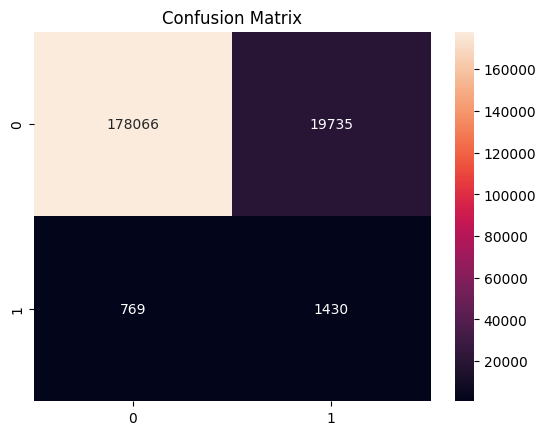

In [96]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_final)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()